# Laboratório 7 - Processamento Morfológico de Imagens

**MCZA018 – Processamento Digital de Imagens - 2026.1**

**Autor:** Allan Hirose Pires de Souza

**Data dos experimentos:** 27/03/2026

**Data de publicação:** 27/03/2026

## Introdução

Neste laboratório vamos estudar o processamento morfológico de imagens. Morfologia matemática é um conjunto de operações que processam imagens baseando-se em formas (elementos estruturantes). As operações basicas são erosão e dilatação, e a partir delas temos abertura, fechamento e extração de bordas (gradiente morfológico). Vamos aplicar essas operações nas imagens do grupo e avatares, variando o tamanho do kernel, e também vamos fazer um programa com a webcam pra extrair bordas em tempo real.

## Procedimentos Experimentais

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### Atividade 3.a - Erosão, Dilatação, Abertura e Fechamento nas imagens do grupo e avatares

Vamos carregar as imagens, binarizar com Otsu e aplicar as 4 operações morfológicas com kernels de tamanhos diferentes (3x3 até 21x21).

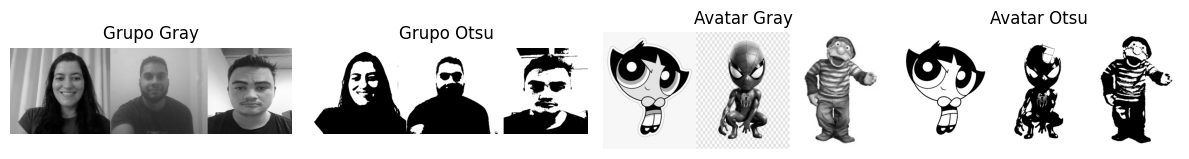

In [4]:
img_grupo = cv2.imread('../Files/imagem.jpeg')
img_grupo_gray = cv2.cvtColor(img_grupo, cv2.COLOR_BGR2GRAY)
_, img_grupo_bin = cv2.threshold(img_grupo_gray, 0, 255, cv2.THRESH_OTSU)

avatar = cv2.imread('../Files/avatar.jpeg')
avatar_gray = cv2.cvtColor(avatar, cv2.COLOR_BGR2GRAY)
_, avatar_bin = cv2.threshold(avatar_gray, 0, 255, cv2.THRESH_OTSU)

plt.figure(figsize=(12, 4))
plt.subplot(141)
plt.imshow(img_grupo_gray, cmap='gray')
plt.title('Grupo Gray')
plt.axis('off')
plt.subplot(142)
plt.imshow(img_grupo_bin, cmap='gray')
plt.title('Grupo Otsu')
plt.axis('off')
plt.subplot(143)
plt.imshow(avatar_gray, cmap='gray')
plt.title('Avatar Gray')
plt.axis('off')
plt.subplot(144)
plt.imshow(avatar_bin, cmap='gray')
plt.title('Avatar Otsu')
plt.axis('off')
plt.tight_layout()
plt.show()

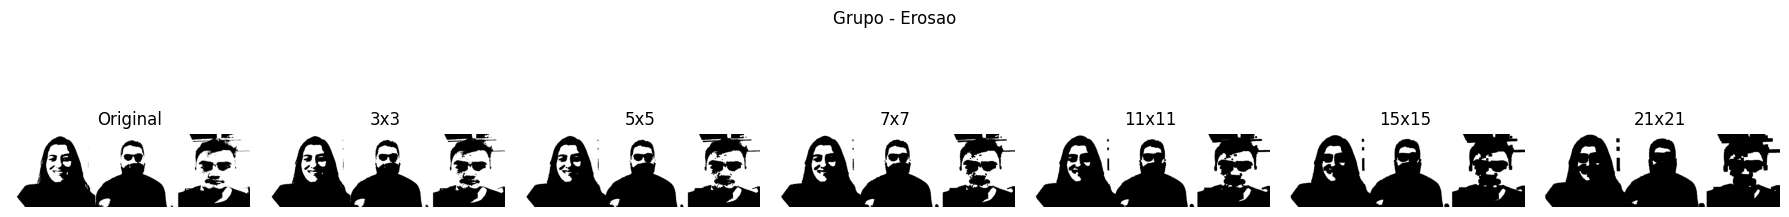

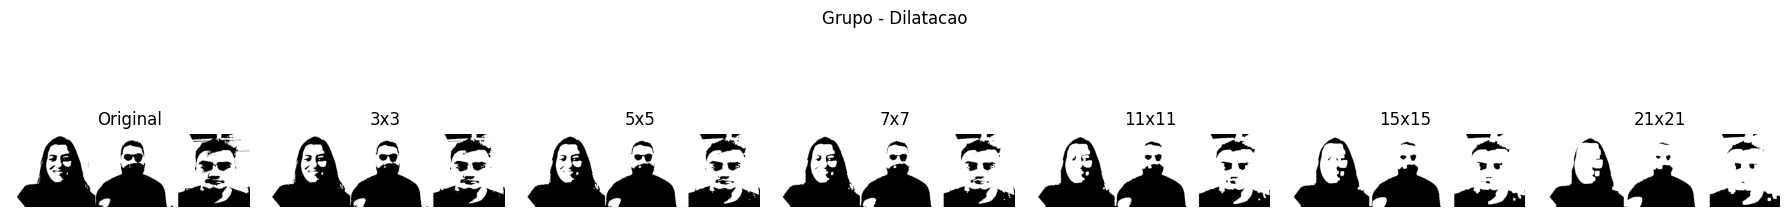

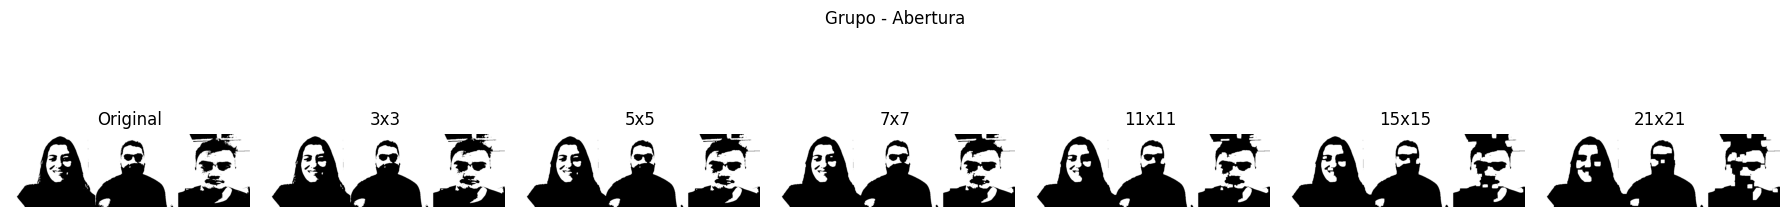

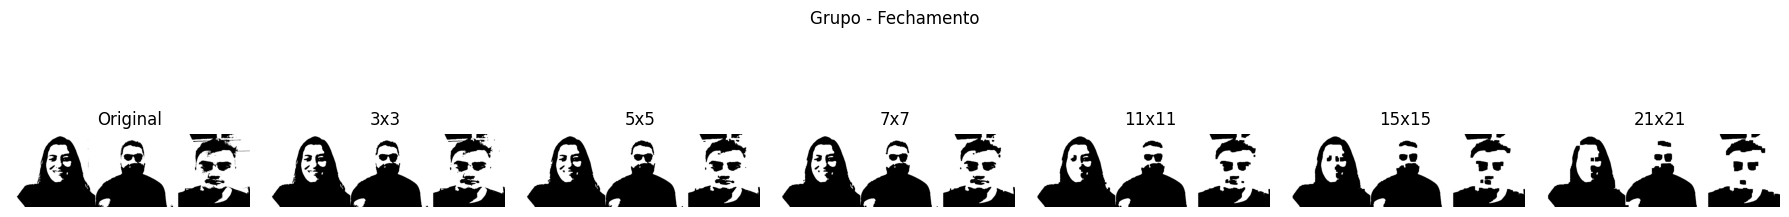

In [5]:
tamanhos = [3, 5, 7, 11, 15, 21]

def aplicar_morfologia(img_bin, nome):
    for op_nome, op in [('Erosao', cv2.MORPH_ERODE), ('Dilatacao', cv2.MORPH_DILATE), 
                         ('Abertura', cv2.MORPH_OPEN), ('Fechamento', cv2.MORPH_CLOSE)]:
        plt.figure(figsize=(18, 3))
        plt.subplot(1, len(tamanhos)+1, 1)
        plt.imshow(img_bin, cmap='gray')
        plt.title('Original')
        plt.axis('off')
        
        for i, t in enumerate(tamanhos):
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (t, t))
            resultado = cv2.morphologyEx(img_bin, op, kernel)
            plt.subplot(1, len(tamanhos)+1, i+2)
            plt.imshow(resultado, cmap='gray')
            plt.title(f'{t}x{t}')
            plt.axis('off')
        
        plt.suptitle(f'{nome} - {op_nome}')
        plt.tight_layout()
        plt.show()

aplicar_morfologia(img_grupo_bin, "Grupo")

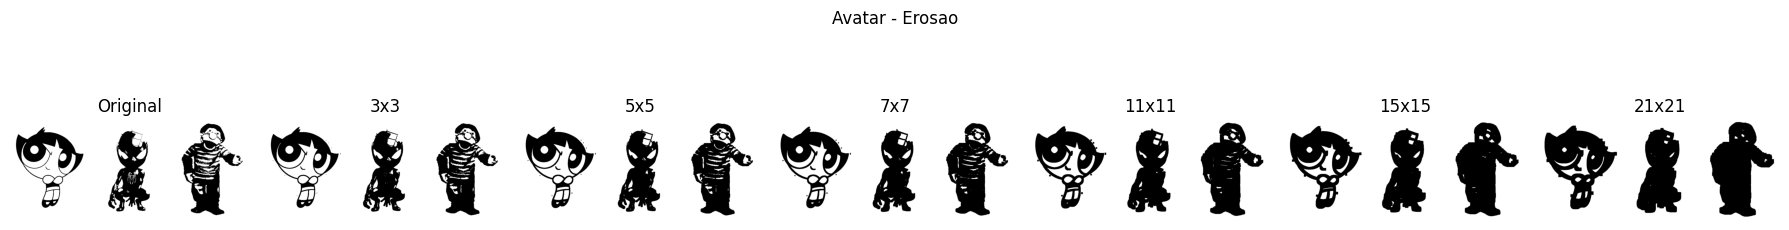

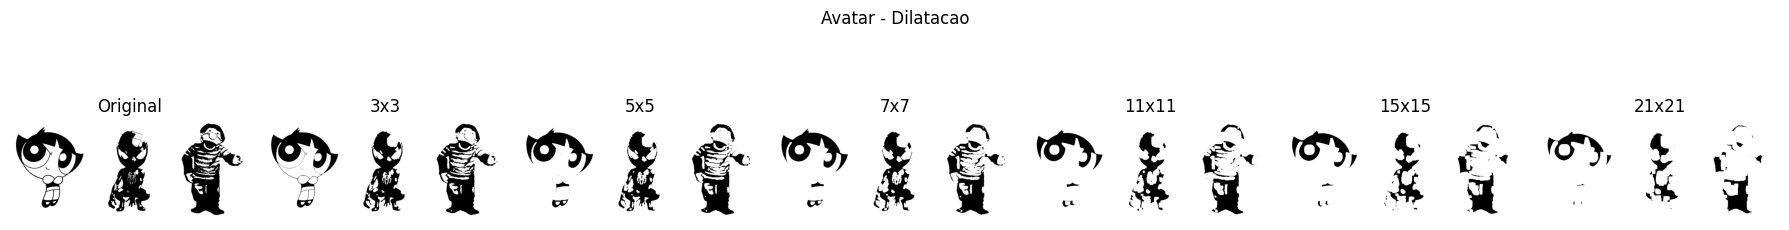

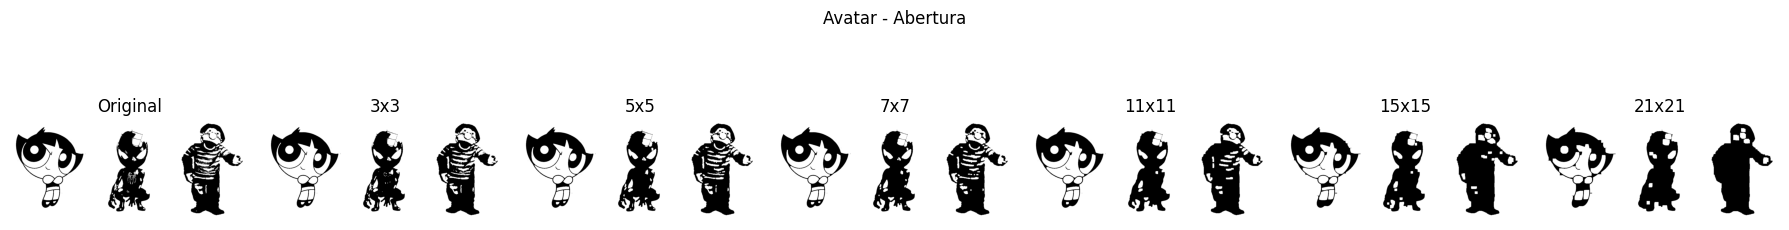

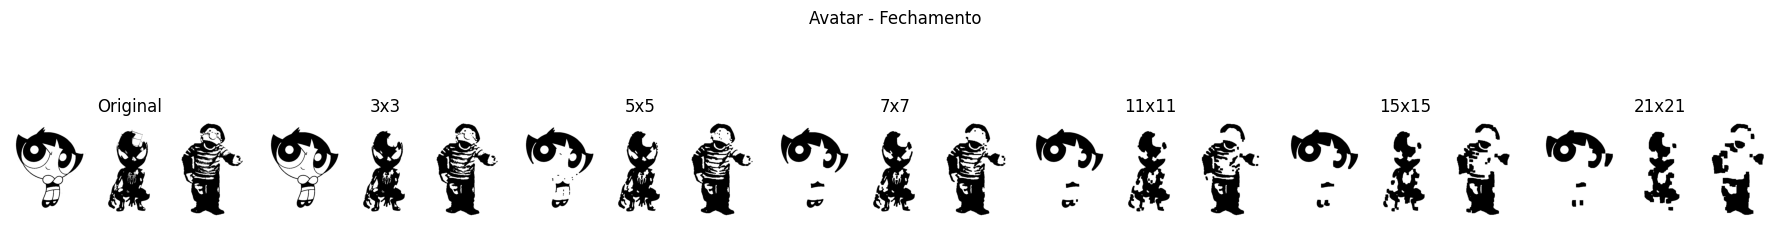

In [6]:
aplicar_morfologia(avatar_bin, "Avatar")

**Análise 3.a:**

**Erosão:** conforme o kernel aumenta de 3x3 até 21x21 as regiões brancas vão diminuindo cada vez mais. Com kernel pequeno (3x3) a mudança é sutil, mas com 21x21 a imagem perde muito detalhe e as areas brancas ficam bem finas ou somem. Ruidos pequenos brancos são eliminados.

**Dilatação:** é o oposto da erosão. As regiões brancas vão crescendo e engrossando. Com kernels grandes (15x15, 21x21) as regiões brancas se juntam e preenchem buracos. Objetos proximos acabam se fundindo.

**Abertura (erosão + dilatação):** remove ruídos pequenos sem alterar muito o tamanho dos objetos maiores. Com kernels grandes, objetos menores desaparecem completamente mas os maiores mantém o tamanho aproximado.

**Fechamento (dilatação + erosão):** preenche buracos e falhas nos objetos. Com kernels grandes os buracos maiores são preenchidos e objetos proximos se conectam, mas o tamanho geral dos objetos se mantém.

**Sobre a binarização:** a binarização com Otsu influiu bastante no resultado final. Se o limiar não for bom, a imagem binária já começa com muitos artefatos e as operações morfológicas amplificam esses problemas. O Otsu funcionou razoavelmente bem nas nossas imagens, mas em imagens com iluminação desigual talvez precisasse de limiarização adaptativa antes de aplicar morfologia. No geral o Otsu foi o método mais pratico porque é automatico e deu resultados aceitáveis.

### Atividade 3.b - Extração de Fronteiras com Webcam (Gradiente Morfológico)

O programa abaixo captura a webcam, binariza com Otsu e aplica o gradiente morfológico em tempo real. Mostra lado a lado a imagem original e as bordas extraídas. Teclas: '+'/'-' mudam o tamanho do kernel, 'g' grava video, 'q' sai.

In [7]:
cap = cv2.VideoCapture(0)
kernel_size = 3
gravando = False
out = None

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, binaria = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    gradiente = cv2.morphologyEx(binaria, cv2.MORPH_GRADIENT, kernel)
    
    gradiente_bgr = cv2.cvtColor(gradiente, cv2.COLOR_GRAY2BGR)
    cv2.putText(frame, f'Kernel: {kernel_size}x{kernel_size}', (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    resultado = cv2.hconcat([frame, gradiente_bgr])
    
    if gravando and out is not None:
        out.write(resultado)
    
    cv2.imshow('Gradiente Morfologico - Webcam', resultado)
    
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('+') or key == ord('='):
        kernel_size = min(21, kernel_size + 2)
    elif key == ord('-'):
        kernel_size = max(3, kernel_size - 2)
    elif key == ord('g'):
        if not gravando:
            h, w = resultado.shape[:2]
            fourcc = cv2.VideoWriter_fourcc(*'XVID')
            out = cv2.VideoWriter('video_gradiente.avi', fourcc, 20.0, (w, h))
            gravando = True
            print("Gravando...")
        else:
            gravando = False
            out.release()
            out = None
            print("Gravacao finalizada.")

if out is not None:
    out.release()
cap.release()
cv2.destroyAllWindows()

**Análise 3.b:**

Com kernel 3x3 as bordas extraídas são bem finas e capturam bastante detalhe, mas também pegam muito ruido da binarização. Conforme aumenta o kernel (5x5, 7x7, etc) as bordas ficam mais grossas e o ruido fino some, mas perde detalhes menores.

Artefatos observados:
- Com kernel pequeno aparece muito ruido nas bordas porque a binarização do Otsu varia entre frames e gera bordas instáveis
- Com kernel grande as bordas ficam muito grossas e objetos proximos se fundem numa borda só
- Quando a iluminação muda (pessoa se move, sombras) a binarização muda e as bordas "piscam" bastante
- Areas com gradiente suave de luz geram bordas falsas que ficam aparecendo e sumindo
- O Otsu as vezes erra o limiar quando tem muita area clara ou escura no frame, causando bordas em lugares inesperados

### Exercício 4.a - Operadores morfológicos nas imagens do projeto final

Aplicamos os operadores morfológicos na imagem do grupo como parte do projeto. O objetivo é usar abertura pra limpar ruidos na binarização e fechamento pra preencher falhas, melhorando a segmentação das pessoas na imagem.

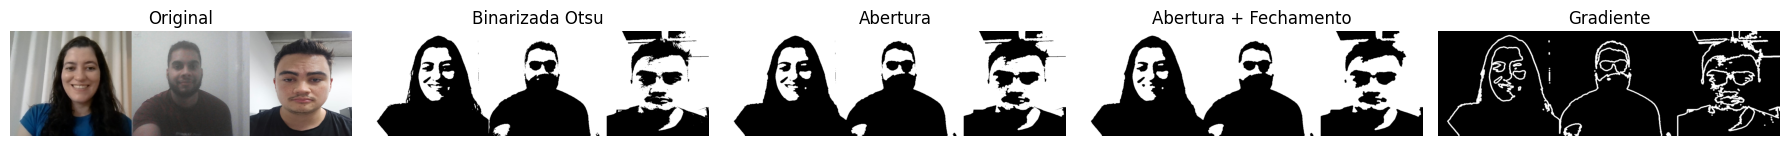

A abertura removeu os ruidos pequenos e o fechamento preencheu as falhas.
A combinação abertura+fechamento deu o melhor resultado pra segmentar as pessoas.
O gradiente extraiu as bordas dos objetos na cena.


In [8]:
img_proj = cv2.imread('../Files/imagem.jpeg')
img_proj_gray = cv2.cvtColor(img_proj, cv2.COLOR_BGR2GRAY)
_, img_proj_bin = cv2.threshold(img_proj_gray, 0, 255, cv2.THRESH_OTSU)

kernel_proj = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

img_proj_open = cv2.morphologyEx(img_proj_bin, cv2.MORPH_OPEN, kernel_proj)
img_proj_close = cv2.morphologyEx(img_proj_bin, cv2.MORPH_CLOSE, kernel_proj)
img_proj_open_close = cv2.morphologyEx(img_proj_open, cv2.MORPH_CLOSE, kernel_proj)
img_proj_gradient = cv2.morphologyEx(img_proj_bin, cv2.MORPH_GRADIENT, kernel_proj)

plt.figure(figsize=(18, 4))
plt.subplot(151)
plt.imshow(cv2.cvtColor(img_proj, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')
plt.subplot(152)
plt.imshow(img_proj_bin, cmap='gray')
plt.title('Binarizada Otsu')
plt.axis('off')
plt.subplot(153)
plt.imshow(img_proj_open, cmap='gray')
plt.title('Abertura')
plt.axis('off')
plt.subplot(154)
plt.imshow(img_proj_open_close, cmap='gray')
plt.title('Abertura + Fechamento')
plt.axis('off')
plt.subplot(155)
plt.imshow(img_proj_gradient, cmap='gray')
plt.title('Gradiente')
plt.axis('off')
plt.tight_layout()
plt.show()

print("A abertura removeu os ruidos pequenos e o fechamento preencheu as falhas.")
print("A combinação abertura+fechamento deu o melhor resultado pra segmentar as pessoas.")
print("O gradiente extraiu as bordas dos objetos na cena.")

## Análise e Discussão

### Questão 5.a - Erosão e Estrutura

Quando aplicamos erosão com kernel 3x3 de uns numa imagem binária com ruidos brancos de 1 pixel, esses ruidos somem completamente. Isso acontece porque na erosão o pixel central só permanece branco se TODOS os pixels na vizinhança do kernel forem brancos. Um ponto isolado de 1 pixel tem vizinhos pretos, então o kernel 3x3 não vai encontrar todos uns na vizinhança e o pixel central vira preto. Basicamente a erosão "encolhe" as regiões brancas, e pontos de 1 pixel são pequenos demais pra sobreviver a esse encolhimento.

### Questão 5.b - Dilatação e Conectividade

Aplicar dilatação com kernel 3x3 nas letras quebradas faz com que cada pixel branco "cresça" 1 pixel em todas as direções. Isso reconecta partes que estavam separadas por 1 ou 2 pixels de distância, juntando os pedaços das letras. O efeito é que o texto fica mais legível e contínuo.

Porém se o kernel for grande demais (tipo 11x11 ou mais) as letras vão engrossar tanto que elas se juntam umas com as outras, ficando um borrão. Letras vizinhas se fundem e o texto fica ilegível. Além disso os buracos internos das letras (como no 'o', 'a', 'e') são preenchidos e a forma original se perde.

### Questão 5.c - Extração de Contornos (Gradiente)

Se aumentar o elemento estruturante de 3x3 pra 11x11 o contorno resultante fica muito mais grosso. Isso porque a erosão com kernel maior remove mais pixels da borda, então quando subtrai a erosão da imagem original (A - (A erode B)), a diferença é maior e a borda fica mais larga. Com 3x3 a borda tem ~1 pixel de espessura e com 11x11 pode ter ~5 pixels. Bordas mais grossas podem ser uteis pra visualização mas perdem precisão na localização exata do contorno.

### Questão 5.d - Abertura vs. Fechamento

- Para remover pequenos objetos indesejados (como poeira num scan) sem alterar o tamanho dos objetos principais: usa **Abertura (Opening)**. A abertura faz erosão primeiro (que elimina os objetos pequenos) e depois dilatação (que restaura o tamanho dos objetos que sobreviveram). Então a poeira some e os objetos grandes ficam praticamente iguais.

- Para fechar pequenos buracos ou fendas dentro de um objeto sólido: usa **Fechamento (Closing)**. O fechamento faz dilatação primeiro (que preenche os buracos) e depois erosão (que traz o objeto de volta ao tamanho original). Os buracos são preenchidos sem alterar as dimensões externas do objeto.

### Questão 5.e - Análise de Kernel (Geometria)

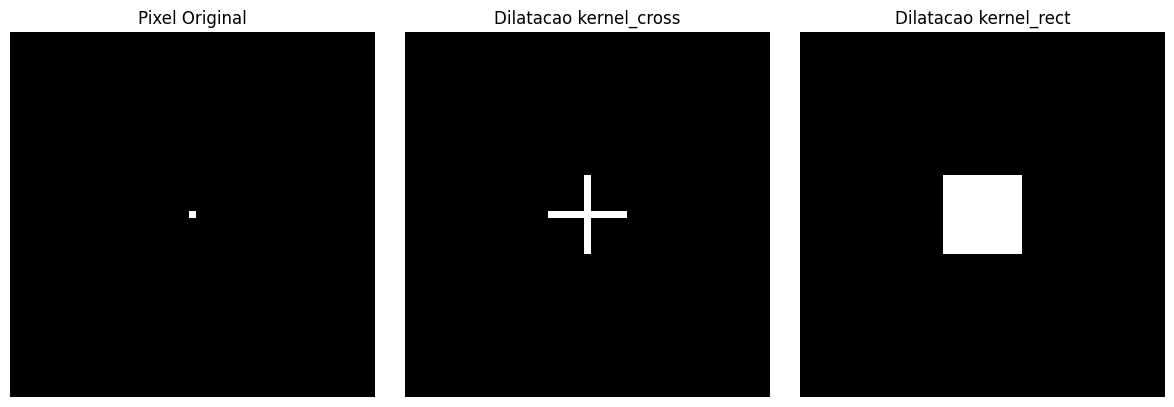

In [9]:
img_pixel = np.zeros((51, 51), dtype='uint8')
img_pixel[25, 25] = 255

kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (11, 11))
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))

dil_cross = cv2.dilate(img_pixel, kernel_cross)
dil_rect = cv2.dilate(img_pixel, kernel_rect)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(img_pixel, cmap='gray')
plt.title('Pixel Original')
plt.axis('off')
plt.subplot(132)
plt.imshow(dil_cross, cmap='gray')
plt.title('Dilatacao kernel_cross')
plt.axis('off')
plt.subplot(133)
plt.imshow(dil_rect, cmap='gray')
plt.title('Dilatacao kernel_rect')
plt.axis('off')
plt.tight_layout()
plt.show()

Com o **kernel_cross** o resultado da dilatação de um unico pixel é uma cruz (formato de +), porque o kernel só tem valores 1 na linha central e coluna central. Então o pixel se expande apenas nas direções horizontal e vertical.

Com o **kernel_rect** o resultado é um quadrado/retângulo preenchido, porque o kernel tem valores 1 em todas as posições. O pixel se expande em todas as direções igualmente formando um bloco sólido.

## Conclusões

Neste lab aprendemos as operações morfológicas basicas: erosão, dilatação, abertura, fechamento e gradiente morfológico. Vimos que o tamanho do kernel influencia muito no resultado - kernels pequenos fazem mudanças sutis e kernels grandes causam transformações drásticas. A erosão remove ruido e afina objetos, a dilatação engrossa e preenche, abertura limpa ruido sem mudar tamanho, e fechamento fecha buracos. O gradiente morfológico extrai bordas e a espessura da borda depende do kernel. Na webcam vimos que a combinação de binarização + morfologia em tempo real gera artefatos por causa das variações de iluminação entre frames.

## Referências

- Rafael C. Gonzalez. Digital Image Processing. 4.ed. Pearson, 2018. Chapter 9 "Morphological Image Processing".
- Tutorial OpenCV e Python: Image Thresholding - https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
- Image Thresholding in OpenCV. Satya Mallick - https://learnopencv.com/opencv-threshold-python-cpp/